In [1]:
import pandas as pd
import numpy as np

In [2]:
dataset=pd.read_csv("cs_students.csv")

In [3]:
dataset

,Student ID,Name,Gender,Age,GPA,Major,Interested Domain,Projects,Future Career,Python,SQL,Java
0,1,John Smith,Male,21,3.5,Computer Science,Artificial Intelligence,Chatbot Development,Machine Learning Researcher,Strong,Strong,Weak
1,2,Alice Johnson,Female,20,3.2,Computer Science,Data Science,Data Analytics,Data Scientist,Average,Strong,Weak
2,3,Robert Davis,Male,22,3.8,Computer Science,Software Development,E-commerce Website,Software Engineer,Strong,Strong,Average
3,4,Emily Wilson,Female,21,3.7,Computer Science,Web Development,Full-Stack Web App,Web Developer,Weak,Strong,Strong
4,5,Michael Brown,Male,23,3.4,Computer Science,Cybersecurity,Network Security,Information Security Analyst,Average,Weak,Strong
...,...,...,...,...,...,...,...,...,...,...,...,...
175,176,Elijah Davis,Male,22,3.7,Computer Science,Web Development,Full-Stack Web App,Web Developer,Weak,Strong,Strong
176,177,Emma Johnson,Female,20,3.6,Computer Science,Cybersecurity,Security Auditing,Information Security Analyst,Strong,Average,Weak
177,178,Liam Wilson,Male,21,3.4,Computer Science,Machine Learning,Natural Language Processing,Machine Learning Engineer,Strong,Average,Weak
178,179,Sophia Johnson,Female,22,3.5,Computer Science,Database Management,SQL Database Administration,Database Administrator,Weak,Strong,Average


In [4]:
dataset.isnull().sum()

Student ID           0
Name                 0
Gender               0
Age                  0
GPA                  0
Major                0
Interested Domain    0
Projects             0
Future Career        0
Python               0
SQL                  0
Java                 0
dtype: int64

In [5]:
def quanQual(dataset):
    quan=[]
    qual=[]
    for columnName in dataset.columns:
        if(dataset[columnName].dtype == "O"):
            qual.append(columnName)
        else:
            quan.append(columnName)
    return quan,qual

In [6]:
quan,qual = quanQual(dataset)

In [7]:
dataset[quan].cov()

,Student ID,Age,GPA
Student ID,2715.000000,-5.695531,0.770670
Age,-5.695531,7.969553,0.101592
GPA,0.770670,0.101592,0.031450


In [8]:
dataset[quan].corr()

,Student ID,Age,GPA
Student ID,1.000000,-0.038720,0.083402
Age,-0.038720,1.000000,0.202925
GPA,0.083402,0.202925,1.000000


In [9]:
dataset.drop("Student ID",inplace=True,axis=1)

In [10]:
dataset

,Name,Gender,Age,GPA,Major,Interested Domain,Projects,Future Career,Python,SQL,Java
0,John Smith,Male,21,3.5,Computer Science,Artificial Intelligence,Chatbot Development,Machine Learning Researcher,Strong,Strong,Weak
1,Alice Johnson,Female,20,3.2,Computer Science,Data Science,Data Analytics,Data Scientist,Average,Strong,Weak
2,Robert Davis,Male,22,3.8,Computer Science,Software Development,E-commerce Website,Software Engineer,Strong,Strong,Average
3,Emily Wilson,Female,21,3.7,Computer Science,Web Development,Full-Stack Web App,Web Developer,Weak,Strong,Strong
4,Michael Brown,Male,23,3.4,Computer Science,Cybersecurity,Network Security,Information Security Analyst,Average,Weak,Strong
...,...,...,...,...,...,...,...,...,...,...,...
175,Elijah Davis,Male,22,3.7,Computer Science,Web Development,Full-Stack Web App,Web Developer,Weak,Strong,Strong
176,Emma Johnson,Female,20,3.6,Computer Science,Cybersecurity,Security Auditing,Information Security Analyst,Strong,Average,Weak
177,Liam Wilson,Male,21,3.4,Computer Science,Machine Learning,Natural Language Processing,Machine Learning Engineer,Strong,Average,Weak
178,Sophia Johnson,Female,22,3.5,Computer Science,Database Management,SQL Database Administration,Database Administrator,Weak,Strong,Average


In [11]:
import seaborn as sns

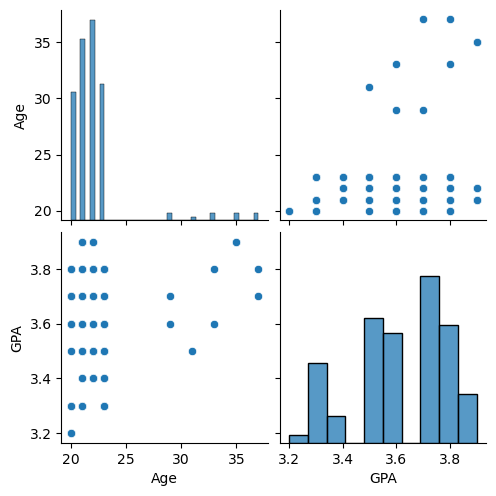

In [12]:
sns.pairplot(dataset)

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(X):
    #calculate VIF
    vif = pd.DataFrame()
    vif["variables"]= X.columns
    vif["VIF"]= [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif

In [14]:
calc_vif(dataset[["Age","GPA"]])

,variables,VIF
0,Age,63.247943
1,GPA,63.247943


### un-paired T-test
Different group(Male, Female) but same condition(Salary)

In [16]:
from scipy.stats import ttest_ind
dataset = dataset.dropna()
male = dataset[dataset["Gender"]=='Male']['GPA']
female = dataset[dataset["Gender"]=='Female']['GPA']
ttest_ind(male,female)

TtestResult(statistic=np.float64(-0.8730296637242402), pvalue=np.float64(0.3838231114433658), df=np.float64(178.0))